### Multi Agent Suprvisor With RAG
Supervisor is a multi-agent architecture where specialized agents are coordinated by a central supervisor agent. The supervisor agent controls all communication flow and task delegation, making decisions about which agent to invoke based on the current context and task requirements.

In this tutorial, you will build a supervisor system with two agents — a research and a math expert. By the end of the tutorial you will:

1. Build specialized research and math agents
2. Build a supervisor for orchestrating them with the prebuilt langgraph-supervisor
3. Build a supervisor 
4. Implement advanced task delegation


In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# LLM Model
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")
llm

c:\Users\heman\Desktop\05 Ultimate RAG Bootcamp Using Langchain,LangGraph and Langsmith by Krish Naik\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000174776CB8C0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000017477B54440>, root_client=<openai.OpenAI object at 0x00000174776C96A0>, root_async_client=<openai.AsyncOpenAI object at 0x0000017477B541A0>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [2]:
# Tavily Tool Implimentation
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from langchain_tavily import TavilySearch
web_search = TavilySearch(max_results=3)
web_search

TavilySearch(max_results=3, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

In [3]:
# generic function to create a retrieval tool
from langchain.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain.agents import Tool

def make_retriever_tool_from_text(file, name, desc):
    # laod docs
    loader = TextLoader(file, encoding="utf-8")
    docs = loader.load()
    
    # split into chunks 
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    
    # embeddings
    embeddings = OpenAIEmbeddings()
    
    # vectorstore
    vs = FAISS.from_documents(chunks, embeddings)
    
    # retriever
    retriever = vs.as_retriever()

    # function
    def tool_func(query:str)->str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in results)
    
    return Tool(name=name, description=desc, func=tool_func)


internal_tool_1 = make_retriever_tool_from_text("research.txt", "InternalResearchNotes", "Search internal research notes for experimental results")
internal_tool_1

Tool(name='InternalResearchNotes', description='Search internal research notes for experimental results', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x0000017456008220>)

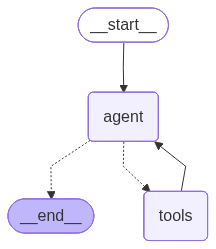

In [4]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model=llm,
    tools=[web_search, internal_tool_1],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent"
)

research_agent

In [5]:
from langgraph.prebuilt import create_react_agent

def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent = create_react_agent(
    model=llm,
    tools=[add, multiply, divide],
    prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent"

)

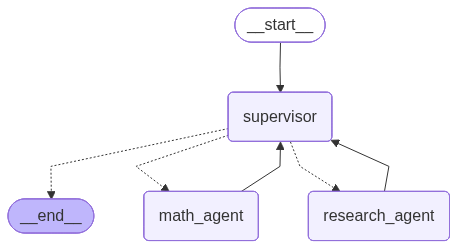

In [ ]:
# create supervisor agent
from langgraph_supervisor import create_supervisor

supervisor = create_supervisor(
    model=llm,
    agents=[research_agent, math_agent],
    prompt=(
         "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."

    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
    
).compile()


workflow = supervisor
workflow

In [7]:
query = {"messages":" list all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10"}

result = workflow.invoke(query)
result

📚 Using tool: InternalResearchNotes


{'messages': [HumanMessage(content=' list all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10', additional_kwargs={}, response_metadata={}, id='64787773-cfa5-47d5-8821-96741ef462ff'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_64unW4otjJPdl9zyp9XdiLl3', 'function': {'arguments': '{}', 'name': 'transfer_to_research_agent'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 142, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CHne7Pav8mM5583M3C3axhlhv9gmH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='supervisor', id='run--9b175534-

In [8]:
print(result["messages"][-1].content)

The transformer variants in production deployments are:

1. **EfficientFormer**
2. **Longformer**
3. **Reformer**
4. **TinyBERT**

And the answer to 5 plus 10 is **15**.
